In [1]:
import os
import glob

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

PTBXL_DIR = os.path.expanduser("~/Documents/physionet-data/ptb-xl-1.0.3")
PTBXL_RECORDS = os.path.join(PTBXL_DIR, "records500")
PTBXL_CSV = os.path.join(PTBXL_DIR, "ptbxl_database.csv")

print("PTB-XL records folder exists:", os.path.exists(PTBXL_RECORDS))
print("PTB-XL database exists:", os.path.exists(PTBXL_CSV))

PTB-XL records folder exists: True
PTB-XL database exists: True


In [4]:
ptbxl_headers = sorted(glob.glob(os.path.join(PTBXL_RECORDS, "**", "*.hea"), recursive=True))

print("Number of PTB-XL records found:", len(ptbxl_headers))
print("Example header:", ptbxl_headers[0])

ptbxl_record_path = ptbxl_headers[0].replace(".hea", "")

record = wfdb.rdrecord(ptbxl_record_path)

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Lead names:", record.sig_name)

Number of PTB-XL records found: 21799
Example header: /Users/hazemharis/Documents/physionet-data/ptb-xl-1.0.3/records500/00000/00001_hr.hea
Signal shape: (5000, 12)
Sampling frequency: 500
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


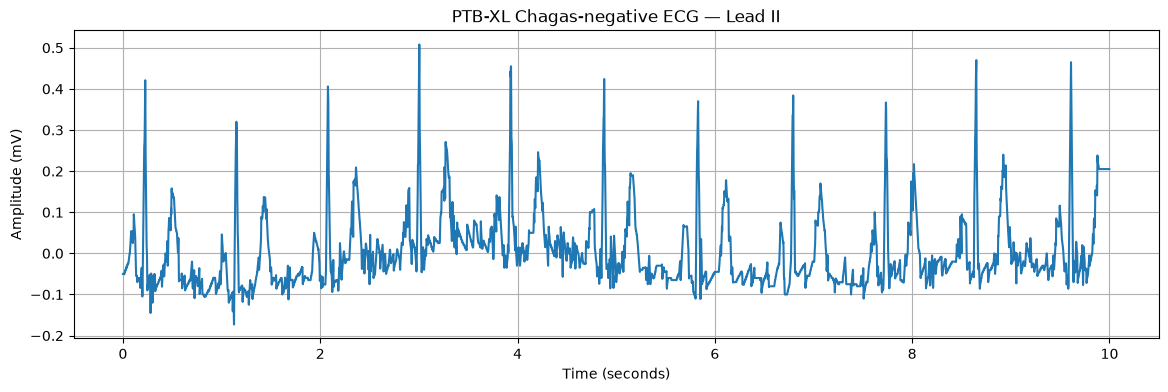

In [5]:
lead_name = "II" if "II" in record.sig_name else record.sig_name[0]
lead_index = record.sig_name.index(lead_name)

ecg = record.p_signal[:, lead_index]
fs = record.fs
time = np.arange(len(ecg)) / fs

plt.figure(figsize=(14, 4))
plt.plot(time, ecg)
plt.title(f"PTB-XL Chagas-negative ECG — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

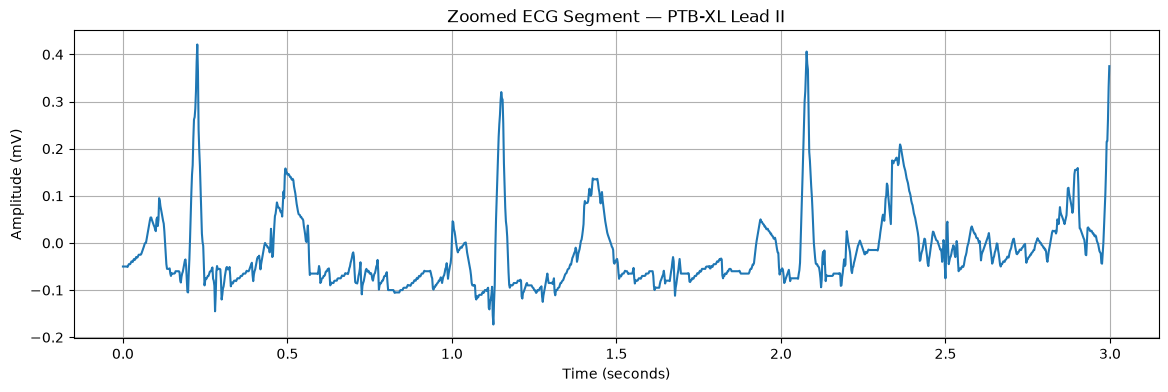

In [6]:
start_sec = 0
end_sec = 3

start_idx = int(start_sec * fs)
end_idx = int(end_sec * fs)

ecg_segment = ecg[start_idx:end_idx]
time_segment = time[start_idx:end_idx]

plt.figure(figsize=(14, 4))
plt.plot(time_segment, ecg_segment)
plt.title(f"Zoomed ECG Segment — PTB-XL Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

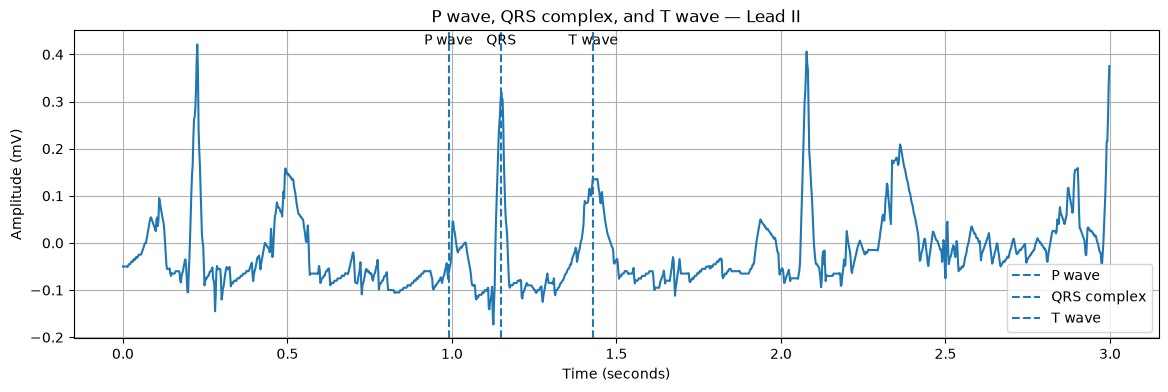

In [8]:
r_time = 1.15

p_time = r_time - 0.16
qrs_time = r_time
t_time = r_time + 0.28

plt.figure(figsize=(14, 4))
plt.plot(time_segment, ecg_segment)

plt.axvline(p_time, linestyle="--", label="P wave")
plt.axvline(qrs_time, linestyle="--", label="QRS complex")
plt.axvline(t_time, linestyle="--", label="T wave")

plt.text(p_time, max(ecg_segment), "P wave", ha="center")
plt.text(qrs_time, max(ecg_segment), "QRS", ha="center")
plt.text(t_time, max(ecg_segment), "T wave", ha="center")

plt.title(f"P wave, QRS complex, and T wave — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

In [9]:
def bandpass_filter(ecg_signal, fs, lowcut=0.5, highcut=40, order=4):
    sos = signal.butter(
        order,
        [lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )
    filtered_signal = signal.sosfiltfilt(sos, ecg_signal)
    return filtered_signal

ecg_bandpassed = bandpass_filter(ecg, fs)

print("Bandpass filtering complete.")

Bandpass filtering complete.


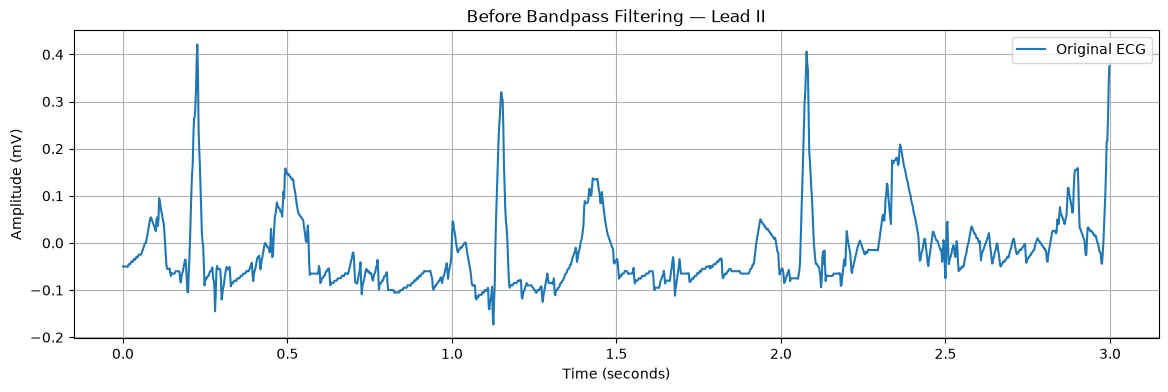

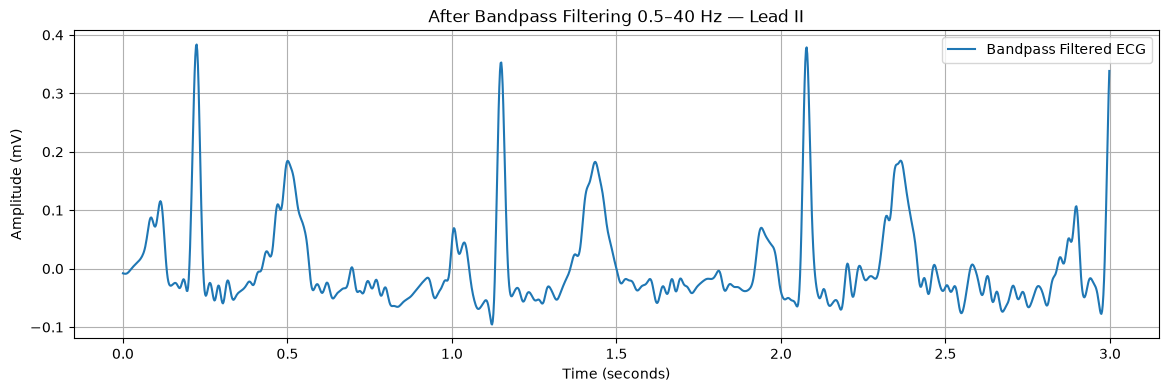

In [10]:
start_sec = 0
end_sec = 3

start_idx = int(start_sec * fs)
end_idx = int(end_sec * fs)

plt.figure(figsize=(14, 4))
plt.plot(time[start_idx:end_idx], ecg[start_idx:end_idx], label="Original ECG")
plt.title(f"Before Bandpass Filtering — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time[start_idx:end_idx], ecg_bandpassed[start_idx:end_idx], label="Bandpass Filtered ECG")
plt.title(f"After Bandpass Filtering 0.5–40 Hz — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
def notch_filter(ecg_signal, fs, notch_freq=50, quality_factor=30):
    b, a = signal.iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )
    filtered_signal = signal.filtfilt(b, a, ecg_signal)
    return filtered_signal

ecg_notched = notch_filter(ecg_bandpassed, fs)

print("50 Hz notch filtering complete.")

50 Hz notch filtering complete.


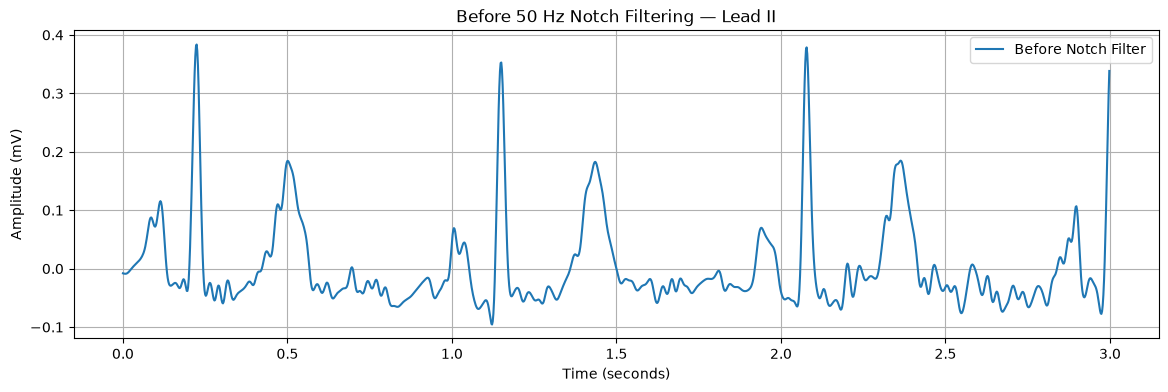

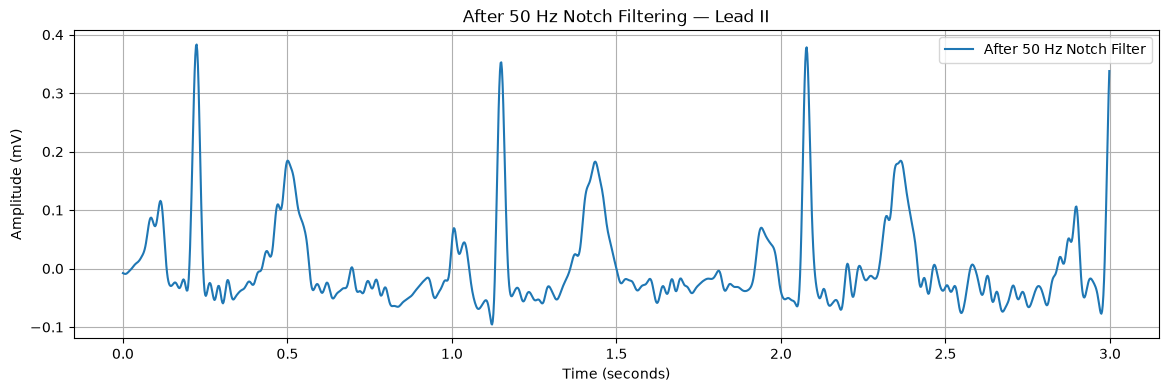

In [12]:
start_sec = 0
end_sec = 3

start_idx = int(start_sec * fs)
end_idx = int(end_sec * fs)

plt.figure(figsize=(14, 4))
plt.plot(time[start_idx:end_idx], ecg_bandpassed[start_idx:end_idx], label="Before Notch Filter")
plt.title(f"Before 50 Hz Notch Filtering — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time[start_idx:end_idx], ecg_notched[start_idx:end_idx], label="After 50 Hz Notch Filter")
plt.title(f"After 50 Hz Notch Filtering — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.legend()
plt.show()

In [13]:
search_roots = [
    os.path.expanduser("~/Documents/cinc2025-practice"),
    os.path.expanduser("~/Documents/physionet-data"),
    os.path.expanduser("~/Downloads")
]

positive_headers = []

for root in search_roots:
    if os.path.exists(root):
        headers = glob.glob(os.path.join(root, "**", "*.hea"), recursive=True)
        
        for header in headers:
            try:
                with open(header, "r", encoding="utf-8", errors="ignore") as f:
                    content = f.read()
                
                if "Chagas label: True" in content:
                    positive_headers.append(header)
            except:
                pass

print("Positive SaMi-Trop headers found:", len(positive_headers))

if len(positive_headers) > 0:
    print("Example positive header:")
    print(positive_headers[0])
else:
    print("No positive records found. We need to manually locate the SaMi-Trop folder.")

Positive SaMi-Trop headers found: 1631
Example positive header:
/Users/hazemharis/Documents/cinc2025-practice/data/samitrop_wfdb/313558.hea


In [17]:
if len(positive_headers) == 0:
    raise FileNotFoundError("No Chagas-positive SaMi-Trop headers were found.")

positive_record_path = positive_headers[0].replace(".hea", "")
positive_record = wfdb.rdrecord(positive_record_path)

print("Positive record path:", positive_record_path)
print("Signal shape:", positive_record.p_signal.shape)
print("Sampling frequency:", positive_record.fs)
print("Lead names:", positive_record.sig_name)

Positive record path: /Users/hazemharis/Documents/cinc2025-practice/data/samitrop_wfdb/313558
Signal shape: (4096, 12)
Sampling frequency: 400
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [18]:
negative_headers = []

for header in ptbxl_headers:
    try:
        with open(header, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read()
        
        if "Chagas label: False" in content:
            negative_headers.append(header)
    except:
        pass

print("Negative PTB-XL headers found:", len(negative_headers))

if len(negative_headers) == 0:
    raise FileNotFoundError("No Chagas-negative PTB-XL headers were found.")

negative_record_path = negative_headers[0].replace(".hea", "")
negative_record = wfdb.rdrecord(negative_record_path)

print("Negative record path:", negative_record_path)
print("Signal shape:", negative_record.p_signal.shape)
print("Sampling frequency:", negative_record.fs)
print("Lead names:", negative_record.sig_name)

Negative PTB-XL headers found: 21799
Negative record path: /Users/hazemharis/Documents/physionet-data/ptb-xl-1.0.3/records500/00000/00001_hr
Signal shape: (5000, 12)
Sampling frequency: 500
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


Positive original sampling frequency: 400
Negative original sampling frequency: 500


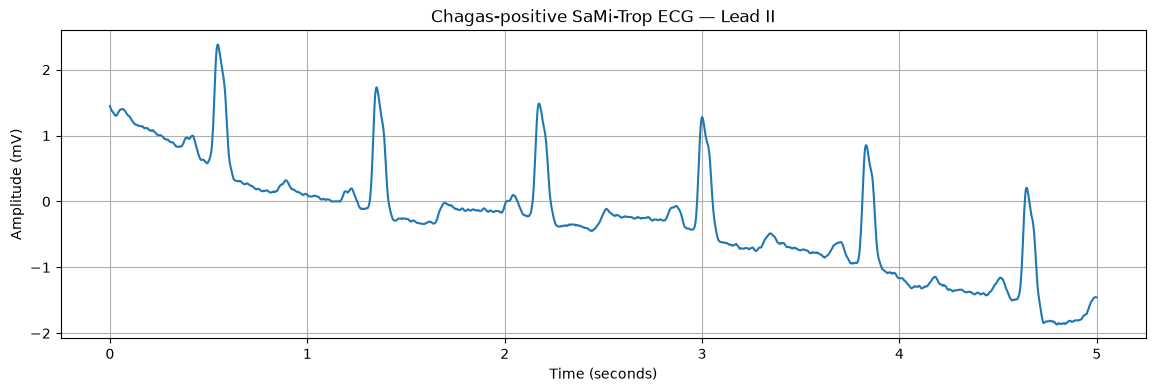

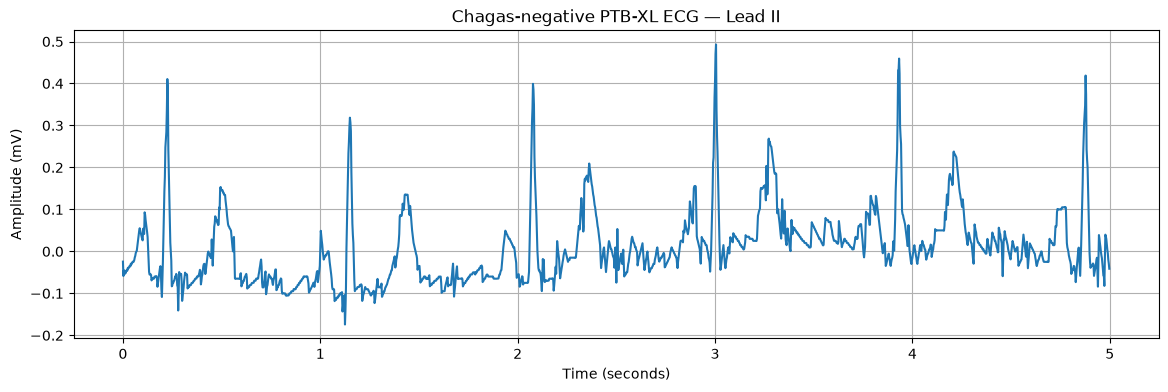

In [19]:
common_fs = 400
duration_sec = 5

positive_lead_name = "II" if "II" in positive_record.sig_name else positive_record.sig_name[0]
negative_lead_name = "II" if "II" in negative_record.sig_name else negative_record.sig_name[0]

positive_lead_index = positive_record.sig_name.index(positive_lead_name)
negative_lead_index = negative_record.sig_name.index(negative_lead_name)

positive_ecg = positive_record.p_signal[:, positive_lead_index]
negative_ecg = negative_record.p_signal[:, negative_lead_index]

positive_fs = positive_record.fs
negative_fs = negative_record.fs

print("Positive original sampling frequency:", positive_fs)
print("Negative original sampling frequency:", negative_fs)

positive_len = int(len(positive_ecg) * common_fs / positive_fs)
negative_len = int(len(negative_ecg) * common_fs / negative_fs)

positive_resampled = signal.resample(positive_ecg, positive_len)
negative_resampled = signal.resample(negative_ecg, negative_len)

n_samples = int(duration_sec * common_fs)

positive_plot = positive_resampled[:n_samples]
negative_plot = negative_resampled[:n_samples]

time_common = np.arange(n_samples) / common_fs

plt.figure(figsize=(14, 4))
plt.plot(time_common, positive_plot)
plt.title(f"Chagas-positive SaMi-Trop ECG — Lead {positive_lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time_common, negative_plot)
plt.title(f"Chagas-negative PTB-XL ECG — Lead {negative_lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()